In [1]:
%matplotlib widget
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import os
print(os.getpid())
%cd ../../

import pylib.mix as mix
import cvxpy as cp
import pylib.qucf_read as qucf_r
import pylib.measurement as mse

from matplotlib import colors
colors_ = ["blue", "red", "green", "gray", "black"]

import scipy
import cupy as cp
from cupyx.scipy.linalg import expm as cu_expm

plt.rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r"\usepackage{amsmath} \boldmath"
})

27574
/media/work/docs/codes/QuCF/scripts-py


In [2]:
path_save_ = "./jupyter-notebooks/Stepanoff/results/"
path_qucf_ = "../QuCF/simulations/Stepanoff/BE"
for i in range(100):
    plt.close()

# Check if CUDA is available
cuda_available = cp.cuda.is_available()

# Get the CUDA device information
if cuda_available:
    device_id = cp.cuda.Device(0)  # Select the first GPU device
    device_props = cp.cuda.runtime.getDeviceProperties(device_id.id)
    
    print("CuPy is using CUDA!")
    print(f"GPU Name: {device_props['name'].decode()}")
    print(f"CUDA Compute Capability: {device_props['major']}.{device_props['minor']}")
else:
    print("CUDA is not available. CuPy is running on the CPU (fallback to NumPy).")

CuPy is using CUDA!
GPU Name: Quadro RTX 4000
CUDA Compute Capability: 7.5


In [3]:
# -------------------------------------------------------
# --- Construct V matrix ---
# -------------------------------------------------------
def plot_2D_subplot(
        ax, fig, X, Y, f, 
        str_title="", fontsize = 30, 
        label_x = '$\\theta/\pi$', label_y = "$\phi/\pi$"
):
    f_max_loc = np.max(np.abs(f))

    cmap = plt.get_cmap("seismic")
    levels = np.linspace(-f_max_loc, f_max_loc, 101) 
    divnorm = colors.BoundaryNorm(levels, ncolors=cmap.N, clip=True)

    cs = ax.pcolormesh(X, Y, f, cmap=cmap, norm=divnorm, shading='gouraud') 
    cb = fig.colorbar(cs, ax = ax)
    cb.ax.ticklabel_format(style="scientific")
    cb.ax.tick_params(labelsize=fontsize)

    offset_text = cb.ax.yaxis.get_offset_text()
    offset_text.set_fontsize(fontsize) 
    offset_text.set_x(4) 

    ax.set_xlabel(label_x, fontsize = fontsize)
    ax.set_ylabel(label_y, fontsize = fontsize)
    ax.set_title(str_title, fontsize = fontsize)
    ax.tick_params(axis='both', which='major', labelsize=fontsize)
    # ax.grid()
    return
# -----------------------------------------------------
def construct_matrices(Nx_init, alpha, flag_opt1):
    Nx = 2 * Nx_init + 1
    Nx2 = Nx * Nx

    Dv = np.zeros((Nx2, Nx2))
    Sv = np.zeros((Nx2, Nx2))
    Av = np.zeros((Nx2, Nx2))

    # --- Choosing coordinate convention ---
    fcoord = None
    if flag_opt1:
        # option 1 
        fcoord = lambda r1, r2: r2 * Nx + r1
    else:
        # option 2
        fcoord = lambda r1, r2: r1 * Nx + r2

    # --- matrix elements ---
    c_arr = np.arange(-Nx_init, Nx_init+1)
    # fd = lambda c1, c2:                  - (c_arr[c1] + c_arr[c2])
    fd = lambda c1, c2:                  - (c_arr[c1] + alpha_ * c_arr[c2])
    fs = lambda c1, c2:        alpha_/2. * (c_arr[c1] + c_arr[c2])
    fa = lambda c1:     (1. - alpha_)/2. *  c_arr[c1]

    # # --- matrix elements ---
    # fd = lambda c1, c2: -(c1 + c2)
    # fs = lambda c1, c2: alpha_/2. * (c1 + c2)
    # fa = lambda c1:     (1. - alpha_)/2. * c1

    # --- Constructing matrices ---
    for r1 in range(Nx):
        for r2 in range(Nx):
            r = fcoord(r1,r2)

            # --- matrix D ---
            Dv[r,r] = fd(r1, r2)

            # --- matrix S ---
            if r2 > 0 and r1 < (Nx-1):
                c1, c2 = r1+1, r2-1
                cL = fcoord(c1, c2)
                Sv[r,cL] = fs(c1, c2)

            if r2 < (Nx-1) and r1 > 0:
                c1, c2 = r1-1, r2+1
                cR = fcoord(c1, c2)
                Sv[r, cR] = fs(c1, c2)

            # --- matrix A ---
            if r2 > 0:
                c1, c2 = r1, r2 - 1
                cL = fcoord(c1, c2)
                Av[r, cL] = fa(c1)

            if r2 < (Nx-1):
                c1, c2 = r1, r2 + 1
                cR = fcoord(c1, c2)
                Av[r, cR] = fa(c1)

    # --- the final matrix ---
    M = Dv + Sv + Av
    return M, Nx
# -----------------------------------------------------
def build_matrix_orig(k):
    n = 2*k + 1
    const = -1.

    # The following code block builds n by n matrices. m1 and mk have nonzero
    # entries in the main diagonal, l1 and lk have nonzero entries in the first
    # lower diagonal,and u1 and uk have nonzero entries in the first upper
    # diagonal.
    m1 = np.eye(n)
    mk = np.diag(np.arange(-k, k + 1), 0)
    l1 = np.diag(np.ones(n - 1), -1)
    lk = np.diag(np.arange(-k, k), -1)
    u1 = np.diag(np.ones(n - 1), 1)
    uk = np.diag(np.arange(-k + 1, k + 1), 1)

    # We now build n^2 by n^2 matrices as Kronecker products of the n by n
    # matrices introduced above.
    m1_mk = np.kron(m1, mk)
    mk_m1 = np.kron(mk, m1)
    l1_mk = np.kron(l1, mk)
    l1_uk = np.kron(l1, uk)
    lk_u1 = np.kron(lk, u1)
    u1_mk = np.kron(u1, mk)
    u1_lk = np.kron(u1, lk)
    uk_l1 = np.kron(uk, l1)

    # Finally, we assemble the generator matrix.
    v2 = alpha_ * (mk_m1 - (uk_l1 + lk_u1) / 2)
    # v2 = mk_m1 - alpha_* (uk_l1 + lk_u1) / 2.
    v1 = m1_mk - (alpha_ * (u1_lk + l1_uk) + (1 - alpha_) * (l1_mk + u1_mk)) / 2.
    M = const * (v1 + v2)

    return M
# -----------------------------------------------------
def get_init_1d(x):
    # y = np.exp(kappa_ * np.sin(x/2.)**2) - 1
    f_loc = lambda x1: np.exp(kappa_ * np.sin(x1/2.)**2) - 1
    y = f_loc(x) / f_loc(np.pi)
    return y
# -----------------------------------------------------
def get_init_2d(x):
    Nx = len(x)
    f_cl = get_init_1d(x)
    y_2d = np.zeros((Nx, Nx))
    for i_phi in range(Nx):
        for i_theta in range(Nx):
            y_2d[i_theta, i_phi] = f_cl[i_theta] * f_cl[i_phi]
    return y_2d
# -------------------------------------------------------
flag_opt1_ = True
Nx_init_ = 32
alpha_ = np.sqrt(20.)
kappa_ = 1.0
t_ = 4.

# --- Matrix in Fourier space ---
M_, Nx_ = construct_matrices(Nx_init_, alpha_, flag_opt1_)
M2_ = build_matrix_orig(Nx_init_)

# --- spatial coordinates ---
x_ = np.linspace(0., 2.*np.pi, Nx_)

# --- initial conditions ---
init_2d_ = get_init_2d(x_)

print("Nx = {:d}".format(Nx_))
mix.is_Hermitian(M_, "M")

Nx = 65
the matrix M is Hermitian


In [ ]:
# print(np.allclose(M_, M2_, atol = 1e-3))

# print()
# mix.print_matrix_colored(M_, n_in_row=10)

# print()
# mix.print_matrix_colored(M2_, n_in_row=10)


True

--- 0:          5.472         0.000         0.000         1.736         0.000         0.000         0.000         0.000         0.000
--- 1:          0.000         4.472         0.000        -2.236         0.000         0.000         0.000         0.000         0.000
--- 2:          0.000         0.000         3.472         0.000         0.000        -1.736         0.000         0.000         0.000
--- 3:          1.736        -2.236         0.000         1.000         0.000         0.000         1.736         0.000         0.000
--- 4:          0.000         0.000         0.000         0.000         0.000         0.000         0.000         0.000         0.000
--- 5:          0.000         0.000        -1.736         0.000         0.000        -1.000         0.000         2.236        -1.736
--- 6:          0.000         0.000         0.000         1.736         0.000         0.000        -3.472         0.000         0.000
--- 7:          0.000         0.000         0.000       

In [4]:
# ----------------------------------------------------------------
# --- Compute the exponential function ---
# ----------------------------------------------------------------
exp_op_ = scipy.linalg.expm(-1.j * M_ * t_)

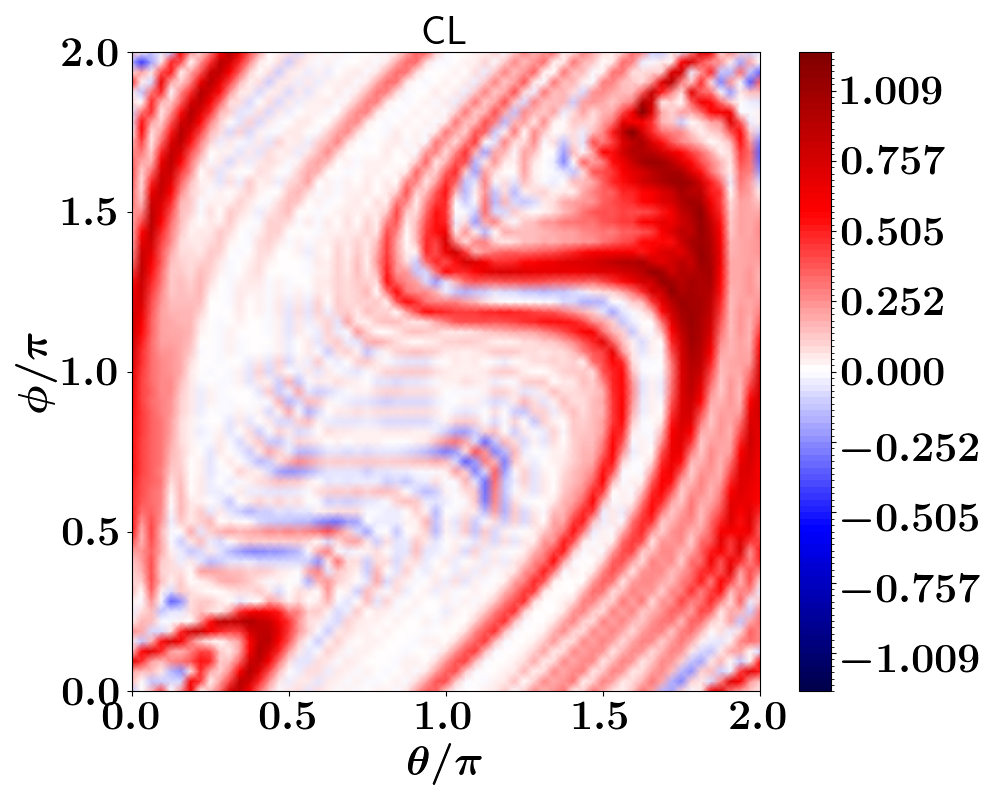

In [5]:
# ----------------------------------------------------------------
# --- Computation ---
# ----------------------------------------------------------------
def computation_in_fourier():
    def rearrange_into_2d(y, N):
        y_new = np.zeros((N, N), dtype = y.dtype)
        for ic in range(N):
            for ir in range(N):
                y_new[ir, ic] = y[ir + ic * N]
        return y_new
    # ----------------------------------------------------------

    # --- Go to Fourier space ---
    init_fft_2d = np.fft.fft2(init_2d_)
    init_fft_2d = np.fft.fftshift(init_fft_2d)
    init_fft_1d = init_fft_2d.flatten()  # row-major, ic0: ir0, ir1, ...; ic1: ir0, ir1, ...

    # --- Computation in Fourier ---
    # psi_t_fourier = np.dot(exp_op_, init_fft_1d)
    psi_t_fourier = np.dot(init_fft_1d, exp_op_)

    # --- Back to real space ---
    psi_t_fourier_2D = rearrange_into_2d(psi_t_fourier, Nx_)
    psi_t_fourier_2D = np.fft.ifftshift(psi_t_fourier_2D)
    psi_t_x = np.fft.ifft2(psi_t_fourier_2D)

    # # --- test: recheck initial conditions ---
    # psi_t_x = np.fft.ifft2(init_fft)

    # --- Plotting ---
    X, Y = np.meshgrid(x_/np.pi, x_/np.pi)

    fig1, axs = plt.subplots(1, 1, figsize=(10,8))
    plot_2D_subplot(axs, fig1, X, Y, psi_t_x.real.transpose(), "CL")
    plt.tight_layout()
    return
# --------------------------------------------------------------------------------------
computation_in_fourier()

dtype('complex128')

In [9]:
xx = np.array(range(-10, 10 + 1))
xx.shape

(21,)

In [10]:
xx = np.arange(-10, 11)
xx.shape

(21,)